이상치 탐지 : Isolation Forest

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [10]:
# 데이터 생성

# 정상 데이터 100개, 2차원
normal_traffic = np.random.normal(loc=50, scale=10, size=(100, 2))
#print(normal_traffic)

# 이상 데이터 10개, 2차원
ano_traffic = np.random.uniform(low=100, high=150, size=(10, 2))
#print(ano_traffic)

# 데이터 병합
traffic_data = np.vstack((normal_traffic, ano_traffic))
#print(traffic_data)

traffic_df = pd.DataFrame(traffic_data, columns=["Request Count", "Response Time"])
traffic_df

,Request Count,Response Time
0,47.356847,52.092962
1,50.437258,30.631495
2,53.804981,48.367340
3,26.582271,48.031263
4,45.603843,46.157305
...,...,...
105,107.690755,111.554836
106,117.816908,113.243723
107,109.250254,117.684286
108,101.173216,145.056340


In [25]:
# 학습 모델 생성
model = IsolationForest(
    n_estimators=150,           # 생성할 결정 트리 개수
    contamination=0.11,         # 데이터에서 이상치가 차지하는 비율
    random_state=42             # 난수 시드 (실행할 때마다 같은 결과를 얻기 위한 설)
)

In [26]:
traffic_df["Anomaly Score"] = model.fit_predict(traffic_df)

In [27]:
traffic_df

,Request Count,Response Time,Anomaly Score
0,47.356847,52.092962,1
1,50.437258,30.631495,1
2,53.804981,48.367340,1
3,26.582271,48.031263,-1
4,45.603843,46.157305,1
...,...,...,...
105,107.690755,111.554836,-1
106,117.816908,113.243723,-1
107,109.250254,117.684286,1
108,101.173216,145.056340,-1


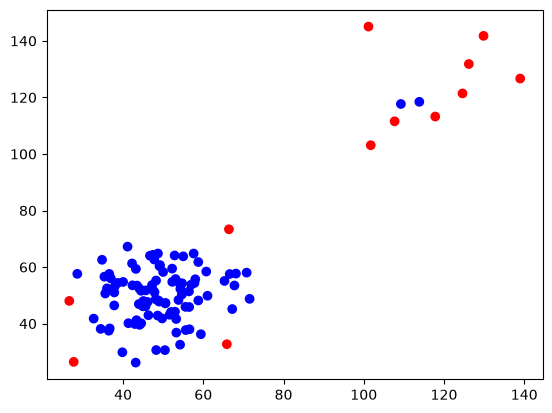

In [29]:
plt.scatter(
    traffic_df["Request Count"],
    traffic_df["Response Time"],
    c=traffic_df["Anomaly Score"].map({1:"blue", -1:"red"})
)

In [31]:
ano_data = traffic_df[traffic_df["Anomaly Score"] == -1]

In [32]:
ano_data

,Request Count,Response Time,Anomaly Score
3,26.582271,48.031263,-1
26,66.387161,73.368540,-1
33,27.692198,26.477948,-1
84,65.862155,32.724364,-1
100,138.988780,126.681669,-1
101,124.611437,121.413723,-1
102,126.191518,131.820319,-1
103,129.860391,141.776176,-1
105,107.690755,111.554836,-1
106,117.816908,113.243723,-1


DBSCAN

In [33]:
from sklearn.cluster import DBSCAN

In [34]:
# DBSCAN 모델 생성
dbscan = DBSCAN(
    eps=15, min_samples=10
)

In [35]:
traffic_df["Cluster"] = dbscan.fit_predict(traffic_df)

In [36]:
traffic_df

,Request Count,Response Time,Anomaly Score,Cluster
0,47.356847,52.092962,1,0
1,50.437258,30.631495,1,0
2,53.804981,48.367340,1,0
3,26.582271,48.031263,-1,0
4,45.603843,46.157305,1,0
...,...,...,...,...
105,107.690755,111.554836,-1,-1
106,117.816908,113.243723,-1,-1
107,109.250254,117.684286,1,-1
108,101.173216,145.056340,-1,-1


In [38]:
traffic_df['Anomaly'] = traffic_df['Cluster'].apply(lambda x: 'Anomaly' if x == -1 else 'Nomal')

In [39]:
traffic_df

,Request Count,Response Time,Anomaly Score,Cluster,Anomaly
0,47.356847,52.092962,1,0,Nomal
1,50.437258,30.631495,1,0,Nomal
2,53.804981,48.367340,1,0,Nomal
3,26.582271,48.031263,-1,0,Nomal
4,45.603843,46.157305,1,0,Nomal
...,...,...,...,...,...
105,107.690755,111.554836,-1,-1,Anomaly
106,117.816908,113.243723,-1,-1,Anomaly
107,109.250254,117.684286,1,-1,Anomaly
108,101.173216,145.056340,-1,-1,Anomaly


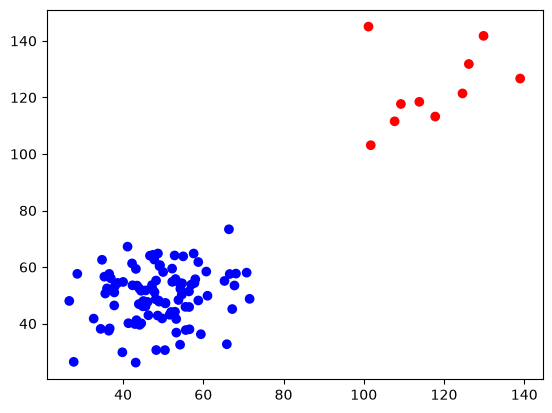

In [40]:
plt.scatter(
    traffic_df['Request Count'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly'].map({'Nomal':'blue', 'Anomaly':'red'})
)